# NBA Game Outcome Prediction

This notebook evaluates a leakage-aware regular-season probability model. The final 2021–2022 holdout is evaluated only after selecting regularization on 2019–2020. Run all cells to populate the observed metrics and charts.


## Context & Methods

### Key assumptions

- Only completed regular-season games are modeled.
- Form resets each season; Elo regresses 25% toward 1500 each offseason.
- Rest is capped at seven days and back-to-backs are explicit.
- The supplied 2022 season is partial and ends December 22.


In [1]:
from pathlib import Path
import os
os.environ.setdefault('MPLCONFIGDIR', '/tmp/nba-matplotlib')
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.calibration import CalibrationDisplay
from nba_prediction.features import FEATURE_COLUMNS, build_model_dataset, load_games
from nba_prediction.modeling import evaluate_predictions, train_logistic_model, walk_forward_scores

DATA_PATH = Path('games.csv')
VALIDATION_SEASONS = [2019, 2020]
HOLDOUT_SEASONS = [2021, 2022]
CANDIDATE_C = [0.01, 0.1, 1.0]


Matplotlib is building the font cache; this may take a moment.


## Data

Load only the game-level columns the model uses, then create features known before tipoff.


In [2]:
games = load_games(DATA_PATH)
model_data = build_model_dataset(games)
data_summary = pd.Series({
    'raw_rows': len(games),
    'model_rows': len(model_data),
    'first_game': model_data.GAME_DATE_EST.min().date(),
    'last_game': model_data.GAME_DATE_EST.max().date(),
    'duplicate_model_game_ids': int(model_data.GAME_ID.duplicated().sum()),
})
data_summary


raw_rows                         26651
model_rows                       20107
first_game                  2003-11-17
last_game                   2022-12-22
duplicate_model_game_ids             0
dtype: object

## Results

### 1. Walk-forward historical performance


In [3]:
development = model_data[model_data.SEASON <= 2018].copy()
validation = model_data[model_data.SEASON.isin(VALIDATION_SEASONS)].copy()
holdout = model_data[model_data.SEASON.isin(HOLDOUT_SEASONS)].copy()
walk_forward_scores(development).round(4)


,season,accuracy,roc_auc,log_loss,brier_score
0,2008,0.7011,0.7475,0.5733,0.1956
1,2009,0.6881,0.7367,0.5852,0.2010
2,2010,0.6958,0.7391,0.5800,0.1979
3,2011,0.6611,0.7116,0.6139,0.2126
4,2012,0.6735,0.7315,0.5866,0.2014
5,2013,0.6629,0.7271,0.6036,0.2088
6,2014,0.6875,0.7348,0.5971,0.2054
7,2015,0.6971,0.7499,0.5764,0.1967
8,2016,0.6480,0.6896,0.6256,0.2180
9,2017,0.6763,0.7207,0.6017,0.2078


### 2. Select regularization without touching the holdout


In [4]:
validation_rows = []
for c_value in CANDIDATE_C:
    candidate = train_logistic_model(c_value).fit(development[FEATURE_COLUMNS], development.home_team_win)
    probability = pd.Series(candidate.predict_proba(validation[FEATURE_COLUMNS])[:, 1], index=validation.index)
    validation_rows.append({'C': c_value, **evaluate_predictions(validation.home_team_win, probability)})
validation_results = pd.DataFrame(validation_rows).sort_values(['log_loss', 'brier_score'])
validation_results.round(4)


,C,accuracy,roc_auc,log_loss,brier_score
0,0.01,0.6459,0.6960,0.6312,0.2204
1,0.10,0.6464,0.6955,0.6319,0.2206
2,1.00,0.6459,0.6954,0.6320,0.2207


### 3. Final untouched holdout evaluation


In [5]:
best_c = float(validation_results.iloc[0].C)
training = model_data[model_data.SEASON <= 2020].copy()
final_model = train_logistic_model(best_c).fit(training[FEATURE_COLUMNS], training.home_team_win)
holdout_probability = pd.Series(final_model.predict_proba(holdout[FEATURE_COLUMNS])[:, 1], index=holdout.index)
holdout_metrics = evaluate_predictions(holdout.home_team_win, holdout_probability)
pd.Series({
    'selected_C': best_c,
    'holdout_games': len(holdout),
    'home_team_baseline_accuracy': holdout.home_team_win.mean(),
    **holdout_metrics,
}).round(4)


selected_C                        0.0100
holdout_games                  1393.0000
home_team_baseline_accuracy       0.5578
accuracy                          0.6418
roc_auc                           0.6766
log_loss                          0.6431
brier_score                       0.2251
dtype: float64

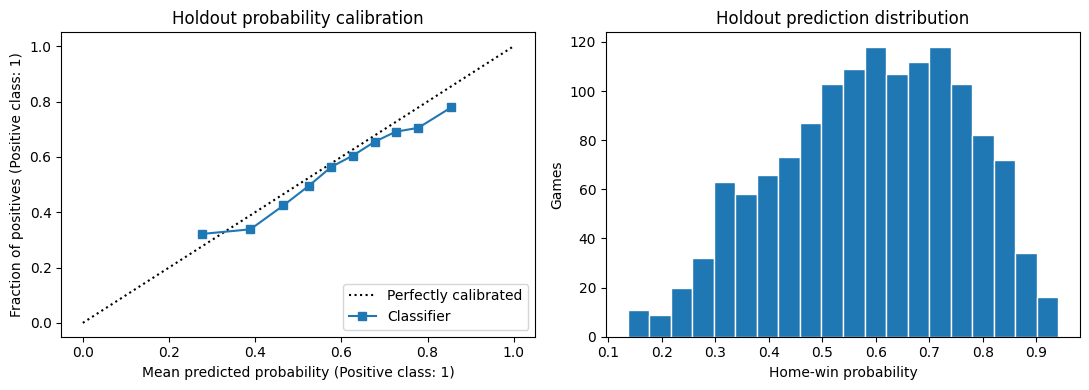

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
CalibrationDisplay.from_predictions(holdout.home_team_win, holdout_probability, n_bins=10, strategy='quantile', ax=axes[0])
axes[0].set_title('Holdout probability calibration')
axes[1].hist(holdout_probability, bins=20, edgecolor='white')
axes[1].set(title='Holdout prediction distribution', xlabel='Home-win probability', ylabel='Games')
plt.tight_layout()


## Takeaways

- Compare the executed holdout accuracy with the displayed home-team baseline.
- Prefer log loss and Brier score when judging probability usefulness.
- Do not reinterpret the partial 2022 season as a complete-season backtest.
- Current-game deployment requires refreshed data and an as-of-date team-state pipeline.
